# PCA

In [ ]:
import pandas as pd
df = pd.read_csv("music_data.csv")

In [ ]:
df.head()

,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_subgenre,danceability,energy,key,loudness,...,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,track_popularity,release_year,genre
0,Dead Prez,7gXuElmegVReY7imkb5bf8,Let's Get Free,90s Hiphop / Gangsta Rap,5yGuoOwRQF3o8NVRRlvCj7,gangster rap,0.725,0.737,4,-7.453,...,0.00417,0.109,0.219,77.161,214067,2HoDr1yVksl19omOhc1zWy,Hip-Hop,57,2000,Hip-Hop
1,Naughty By Nature,4OEP9VlZWOCt1QcOzX0oXF,19 Naughty III,90's Hip Hop Ultimate Collection,4IG024zoaGMurhTFBkMAv9,southern hip hop,0.862,0.642,6,-13.652,...,0.00000,0.272,0.765,99.201,267267,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop
2,Naughty By Nature,6smksVgwxaPFGdSsIloCjo,Anthem Inc.,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,new jack swing,0.776,0.968,4,-4.250,...,0.00000,0.204,0.667,97.765,250173,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop
3,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,Dr. Q's Prescription Playlist💊,6jAPdgY9XmxC9cgkXAVmVv,post-teen pop,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop
4,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,90s-2000s Southern Hip Hop / Crunk,5wsWBmQgDtKa8CEg7wTEMi,southern hip hop,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop


In [ ]:
df.columns

Index(['track_artist', 'track_album_id', 'track_album_name', 'playlist_name',
       'playlist_id', 'playlist_subgenre', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'track_id', 'track_name',
       'track_popularity', 'release_year', 'genre'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6484 entries, 0 to 6483
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_artist       6484 non-null   object 
 1   track_album_id     6484 non-null   object 
 2   track_album_name   6484 non-null   object 
 3   playlist_name      6484 non-null   object 
 4   playlist_id        6484 non-null   object 
 5   playlist_subgenre  6484 non-null   object 
 6   danceability       6484 non-null   float64
 7   energy             6484 non-null   float64
 8   key                6484 non-null   int64  
 9   loudness           6484 non-null   float64
 10  mode               6484 non-null   int64  
 11  speechiness        6484 non-null   float64
 12  acousticness       6484 non-null   float64
 13  instrumentalness   6484 non-null   float64
 14  liveness           6484 non-null   float64
 15  valence            6484 non-null   float64
 16  tempo              6484 

In [ ]:
# Remove duplicates
df = df.drop_duplicates()
df.size

149132

In [ ]:
df.isnull().sum()

,0
track_artist,0
track_album_id,0
track_album_name,0
playlist_name,0
playlist_id,0
playlist_subgenre,0
danceability,0
energy,0
key,0
loudness,0


In [ ]:
# Fill missing numeric values with median

df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity,release_year
count,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.00000,6484.000000,6484.000000
mean,0.656687,0.662695,5.108112,-6.339298,0.541487,0.116708,0.175291,0.028306,0.189283,0.461480,121.143942,225103.89343,60.130475,2013.432603
std,0.152863,0.175067,3.640679,2.571509,0.498314,0.108356,0.218181,0.122330,0.146737,0.220573,28.065763,54901.41406,18.761127,13.324169
min,0.135000,0.045500,0.000000,-23.459000,0.000000,0.023200,0.000015,0.000000,0.009360,0.034900,48.718000,37640.00000,0.000000,1958.000000
25%,0.555000,0.538000,1.000000,-7.621000,0.000000,0.043800,0.018900,0.000000,0.096900,0.293000,99.252000,191661.00000,53.000000,2012.000000
50%,0.671000,0.672000,5.000000,-5.884000,1.000000,0.065300,0.080450,0.000002,0.130000,0.440000,120.073000,216245.00000,63.000000,2018.000000
75%,0.771000,0.799000,8.000000,-4.559000,1.000000,0.153000,0.243000,0.000287,0.237000,0.619000,136.245000,248403.25000,72.000000,2022.000000
max,0.977000,0.998000,11.000000,-0.475000,1.000000,0.918000,0.984000,0.963000,0.984000,0.979000,207.969000,517125.00000,100.000000,2025.000000



Numeric data shape: (6484, 14)

Explained variance ratio for 2 components: 27.715175953819397
Cumulative explained variance (2D): [0.16469443 0.27715176]


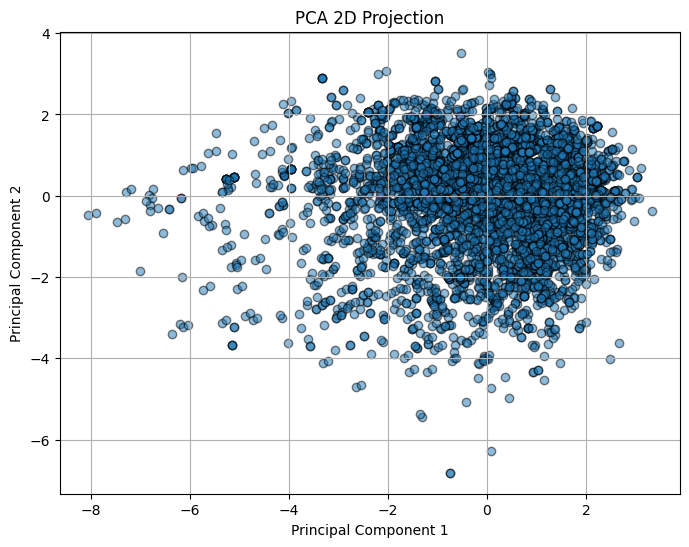

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


# Remove non-numeric columns (for example, identifiers, names, etc.)
numeric_df = df.select_dtypes(include=[np.number])
print("\nNumeric data shape:", numeric_df.shape)

# Normalize the data so each feature has mean=0 and std=1
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

pca_2 = PCA(n_components=2)
pca_2_data = pca_2.fit_transform(scaled_data)
print("\nExplained variance ratio for 2 components:", sum(pca_2.explained_variance_ratio_)*100)
cumulative_2 = np.cumsum(pca_2.explained_variance_ratio_)
print("Cumulative explained variance (2D):", cumulative_2)

# Visualization: 2D scatter plot of the first two principal components
plt.figure(figsize=(8,6))
plt.scatter(pca_2_data[:, 0], pca_2_data[:, 1], alpha=0.5, edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Projection")
plt.grid(True)
plt.show()



Explained variance ratio for 3 components: 37.138589604722725
Cumulative explained variance (3D): [0.16469443 0.27715176 0.3713859 ]


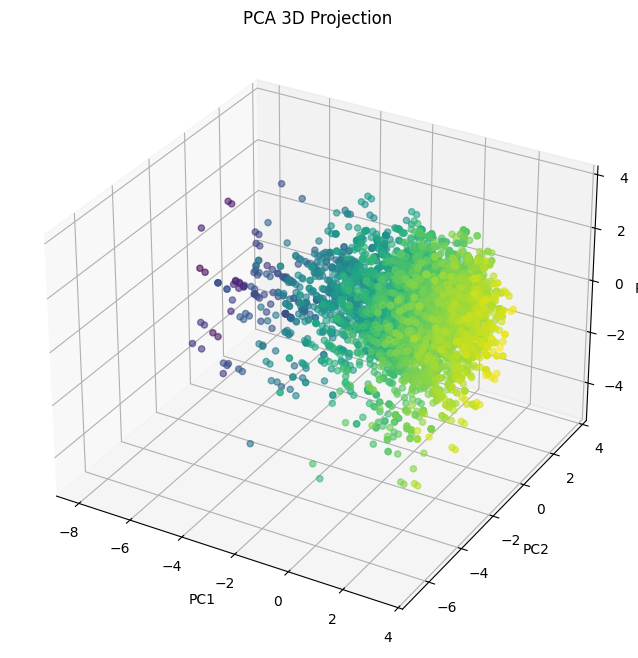

In [ ]:
# --- PCA with 3 Components ---
pca_3 = PCA(n_components=3)
pca_3_data = pca_3.fit_transform(scaled_data)
print("\nExplained variance ratio for 3 components:", sum(pca_3.explained_variance_ratio_)*100)
cumulative_3 = np.cumsum(pca_3.explained_variance_ratio_)
print("Cumulative explained variance (3D):", cumulative_3)

# Visualization: 3D scatter plot of the first three principal components
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_3_data[:, 0], pca_3_data[:, 1], pca_3_data[:, 2],
                     c=pca_3_data[:, 0], cmap='viridis', alpha=0.6)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D Projection")
plt.show()


In [ ]:
# --- Variance Retention ---
# Fit PCA without specifying n_components to see the full spectrum of variance explained.
pca_full = PCA().fit(scaled_data)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
dimensions_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("\nNumber of dimensions required to retain at least 95% variance:", dimensions_95)

# --- Top Three Eigenvalues ---
eigenvalues = pca_full.explained_variance_
top_three_eigenvalues = eigenvalues[:3]
print("Top three eigenvalues:", top_three_eigenvalues)


Number of dimensions required to retain at least 95% variance: 12
Top three eigenvalues: [2.30607773 1.57464541 1.31948141]


In [ ]:
pca_df = pd.DataFrame(pca_3_data, columns=[f'PC{i+1}' for i in range(3)])

print(pca_df.head())

        PC1       PC2       PC3
0 -0.192886  0.203140  0.768767
1 -1.303115 -0.051505  2.307406
2  1.702600 -0.821421  1.577519
3  1.526485 -0.272184  0.874048
4  1.526485 -0.272184  0.874048


Explained Variance: [16.46944341 11.24573255  9.42341365  8.90330217  8.35207438  7.39864499
  6.92509711  6.54386824  5.92438177  5.25854705  4.70349283  4.6359495
  2.81854217  1.39751019]

Cumulative Explained Variance: [ 16.46944341  27.71517595  37.1385896   46.04189177  54.39396615
  61.79261114  68.71770826  75.26157649  81.18595826  86.44450531
  91.14799814  95.78394764  98.60248981 100.        ] 



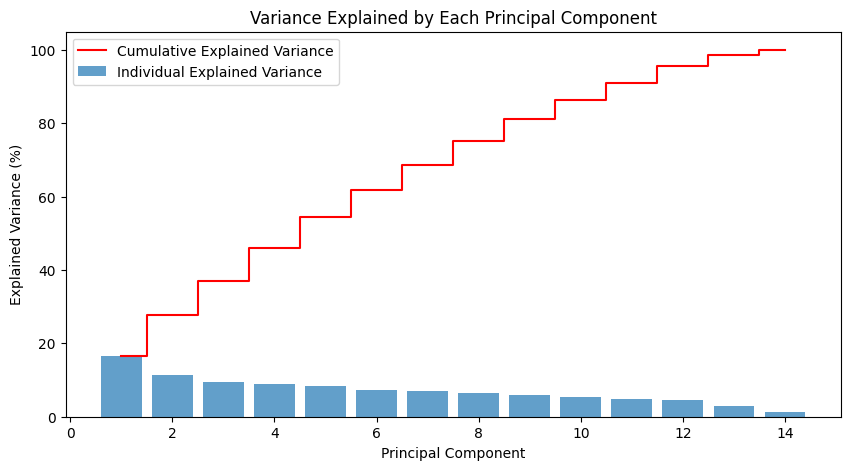

In [ ]:
# variance explained plot

plt.figure(figsize=(10, 5))
explained_variance = pca_full.explained_variance_ratio_ * 100  # Convert to percentage
cumulative_variance = np.cumsum(explained_variance)  # Cumulative sum

print("Explained Variance:", explained_variance)
print("\nCumulative Explained Variance:", cumulative_variance,"\n")
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center', label='Individual Explained Variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', color='red', label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Variance Explained by Each Principal Component')
plt.legend()
plt.show()